In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10,Flowers102


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
])

In [3]:
DATA_DIR = r'/home/pcdm/Desktop/butterfly'
model_algo="alexnet"

In [4]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImagecsvDataset(DATA_DIR+"/train",'/home/pcdm/Desktop/butterfly/Training_set.csv',transform)

size=len(images)

generator = torch.Generator()
generator.manual_seed(124)

valid_size = int(0.2 * size)
train_size = int(size - valid_size )

trainset, validset = random_split(images, (train_size, valid_size), generator=generator)


In [6]:
valid_size

1299

In [7]:
train_size

5200

In [8]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=False, batch_size=batch_size,num_workers=4)
valid_dl = DataLoader(validset,shuffle=False, batch_size=batch_size,num_workers=4)
criterion = nn.CrossEntropyLoss()

In [9]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_1.pth')

In [10]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.25367087486844797, 0.9286538461538462)

In [11]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.5965662491697821, 0.8437259430331023)

In [12]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [13]:
each_accu=p
each_accu

ADONIS                       0.970149
AFRICAN GIANT SWALLOWTAIL    0.982759
AMERICAN SNOOT               0.842105
AN 88                        1.000000
APPOLLO                      0.970149
                               ...   
ULYSES                       0.955882
VICEROY                      0.492308
WOOD SATYR                   1.000000
YELLOW SWALLOW TAIL          0.967742
ZEBRA LONG WING              1.000000
Length: 75, dtype: float64

In [14]:
each_f1=2*p*r/(p+r)
each_f1

ADONIS                       0.984848
AFRICAN GIANT SWALLOWTAIL    0.991304
AMERICAN SNOOT               0.914286
AN 88                        1.000000
APPOLLO                      0.955882
                               ...   
ULYSES                       0.955882
VICEROY                      0.659794
WOOD SATYR                   0.983333
YELLOW SWALLOW TAIL          0.944882
ZEBRA LONG WING              0.992366
Length: 75, dtype: float64

In [15]:
targetF=[x  for x in each_accu.nlargest(10).index.map(trainset.dataset.classess)]
targetF

[3, 10, 14, 16, 24, 33, 37, 40, 44, 45]

In [16]:
targetF=[x  for x in each_f1.nsmallest(30).index.map(trainset.dataset.classess)]
targetF

[71,
 38,
 44,
 27,
 57,
 19,
 26,
 31,
 37,
 22,
 55,
 16,
 50,
 35,
 20,
 66,
 65,
 68,
 8,
 64,
 17,
 2,
 56,
 7,
 25,
 46,
 42,
 40,
 13,
 34]

In [17]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode='classf1'

if(split_mode=='classf1'):
    targetF=[x  for x in each_f1.nsmallest(30).index.map(trainset.dataset.classess)]
else:
    targetF=[x  for x in each_accu.nsmallest(30).index.map(trainset.dataset.classess)]

split=(split_mode,targetF)
indexF,indexT=split_data(model_0,train_dl,split)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(2093, 3107)

In [18]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split)
len(indexF_v),len(indexT_v)

(498, 801)

In [19]:
# d_data,d_target=decision_split(train_dl,model_0)
# d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [20]:
# decisionset=DecisionDataset(d_data,d_target)
# decisionset_v=DecisionDataset(d_v_data,d_v_target)

Epoch=0,train_loss=0.09771130928626427,train_accu=0.9675
Epoch=0,valid_loss=0.18513820702934192,valid_accu=0.9276366435719784
0
Epoch=1,train_loss=0.055663945729342794,train_accu=0.9836538461538461
Epoch=1,valid_loss=0.16987722000541644,valid_accu=0.9414934565050038
0
Epoch=2,train_loss=0.03414805884544666,train_accu=0.9884615384615385
Epoch=2,valid_loss=0.15838424548122448,valid_accu=0.9430331023864511
0
Epoch=3,train_loss=0.024021005399811727,train_accu=0.9926923076923077
Epoch=3,valid_loss=0.15579399590117368,valid_accu=0.9515011547344111
0
Epoch=4,train_loss=0.014862597539232901,train_accu=0.9951923076923077
Epoch=4,valid_loss=0.1601462248853301,valid_accu=0.9507313317936874
Epoch=5,train_loss=0.012639619278757331,train_accu=0.9971153846153846
Epoch=5,valid_loss=0.18109033248667605,valid_accu=0.9445727482678984
Epoch=6,train_loss=0.007025172841699364,train_accu=0.9982692307692308
Epoch=6,valid_loss=0.17515533987190388,valid_accu=0.9484218629715165
Epoch=7,train_loss=0.0075958953535

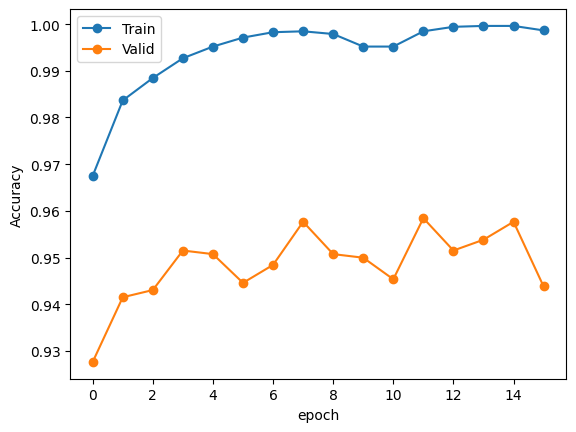

In [21]:
# from torchsampler import ImbalancedDatasetSampler
# decision_dl = DataLoader(decisionset, batch_size=32)
# # decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
# decision_v_dl = DataLoader(decisionset_v, batch_size=32)
# train_dl=DataLoader(trainset, batch_size=32,sampler=ImbalancedDatasetSampler(trainset))
model_decision=model_train(model_algo,train_dl,valid_dl,"decision",70,model_0=model_0)

In [22]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=False, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=False, batch_size=batch_size)

Epoch=0,train_loss=0.11524379946949435,train_accu=0.9732861280978435
Epoch=0,valid_loss=0.369209116020155,valid_accu=0.9101123595505618
0
Epoch=1,train_loss=0.05227300740411552,train_accu=0.9887351142581268
Epoch=1,valid_loss=0.3467265427224199,valid_accu=0.9238451935081149
0
Epoch=2,train_loss=0.029753190576628518,train_accu=0.9919536530415192
Epoch=2,valid_loss=0.3335084022300669,valid_accu=0.9288389513108615
0
Epoch=3,train_loss=0.04006923523158708,train_accu=0.9900225297714838
Epoch=3,valid_loss=0.38924128974272815,valid_accu=0.9138576779026217
Epoch=4,train_loss=0.010202952624949989,train_accu=0.9967814612166077
Epoch=4,valid_loss=0.349288908171743,valid_accu=0.9350811485642946
0
Epoch=5,train_loss=0.006080946314850319,train_accu=0.9990344383649823
Epoch=5,valid_loss=0.3792320489604375,valid_accu=0.9263420724094882
Epoch=6,train_loss=0.006039619430040499,train_accu=0.9980688767299646
Epoch=6,valid_loss=0.4384765258703041,valid_accu=0.9288389513108615
Epoch=7,train_loss=0.009853409

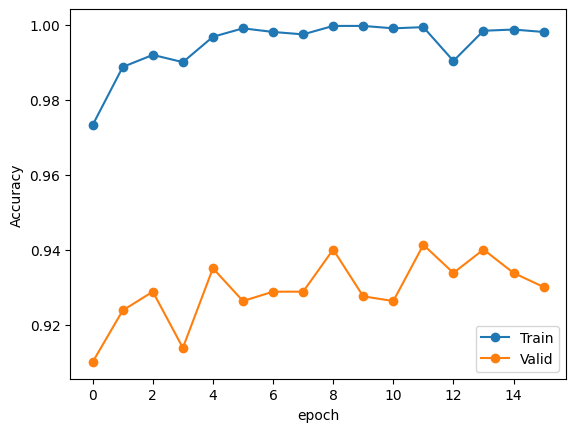

In [23]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70,model_0=model_0)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.30126250882326444,train_accu=0.8996655518394648
Epoch=0,valid_loss=0.5952763533496473,valid_accu=0.8092369477911646
0
Epoch=1,train_loss=0.16593394712204576,train_accu=0.9479216435738175
Epoch=1,valid_loss=0.5567474109101965,valid_accu=0.8393574297188755
0
Epoch=2,train_loss=0.12999586956250683,train_accu=0.9627329192546584
Epoch=2,valid_loss=0.5207063117659235,valid_accu=0.8413654618473896
0
Epoch=3,train_loss=0.07042848126944092,train_accu=0.9765886287625418
Epoch=3,valid_loss=0.5047447379813137,valid_accu=0.8353413654618473
Epoch=4,train_loss=0.05019228539440284,train_accu=0.985188724319159
Epoch=4,valid_loss=0.5032512380416134,valid_accu=0.8614457831325302
0
Epoch=5,train_loss=0.05643679327484998,train_accu=0.9827998088867654
Epoch=5,valid_loss=0.5774147922255428,valid_accu=0.8514056224899599
Epoch=6,train_loss=0.04054853261385702,train_accu=0.989010989010989
Epoch=6,valid_loss=0.567349087282357,valid_accu=0.8674698795180723
0
Epoch=7,train_loss=0.0578101934184

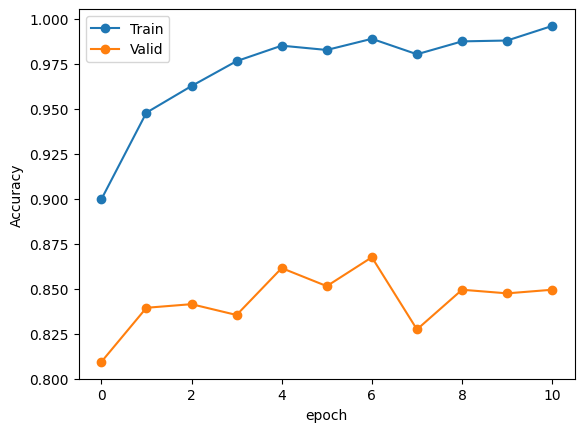

In [24]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70,model_0=model_0)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [25]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,train_dl,len(trainset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.005637873818139689, 0.9984615384615385)

In [26]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,valid_dl,len(validset),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.17196165517548256, 0.9561200923787528)

In [27]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.0038243526200590397, 0.9993562922433216)

In [28]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.04392255168822868, 0.9880554228380315)

In [29]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.4263377029369684, 0.9413233458177278)

In [30]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.5435441660593792, 0.8674698795180723)

In [31]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.018461151355877517, 0.9946153846153846, 2093)

In [32]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.4795445290044971, 0.9099307159353349, 498)

In [33]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.03827724971127911, 0.9930769230769231, 2088, 3112)

In [34]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(1.069964850861995, 0.8829869130100076, 479, 820)

In [35]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [52]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'split_mode = {split}')
df

split_mode = ('classf1', [71, 38, 44, 27, 57, 19, 26, 31, 37, 22, 55, 16, 50, 35, 20, 66, 65, 68, 8, 64, 17, 2, 56, 7, 25, 46, 42, 40, 13, 34])


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.253671,0.928654,0.596566,0.843726
1,Model_Decision,0.005638,0.998462,0.171962,0.956120
2,Model_T,0.003824,0.999356,0.426338,0.941323
3,Model_F,0.043923,0.988055,0.543544,0.867470
4,Total_Model,0.038277,0.993077,1.069965,0.882987
5,Total_Model_with_perfect_decision,0.018461,0.994615,0.479545,0.909931


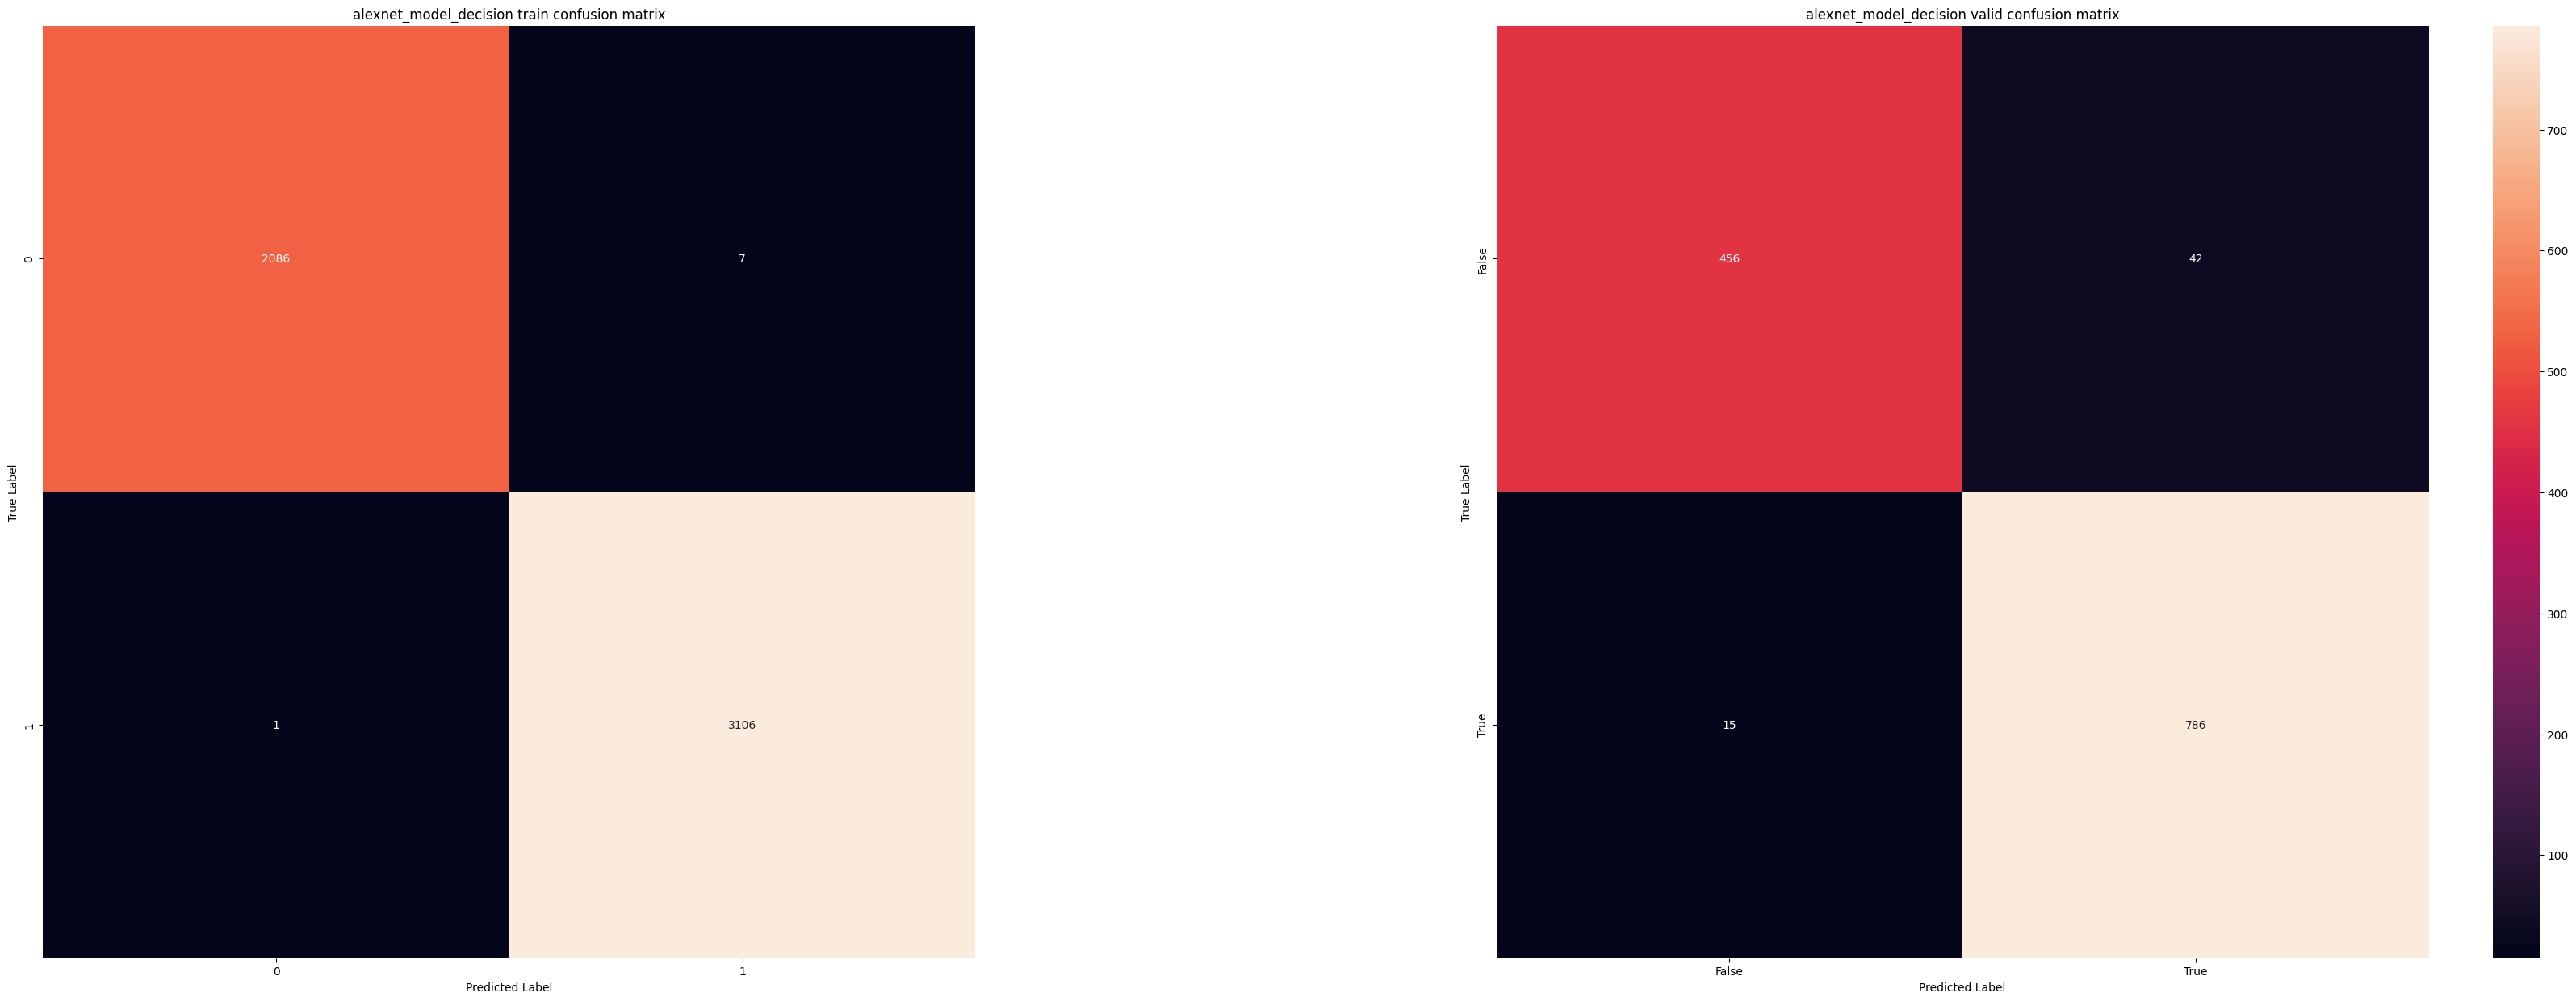

In [37]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

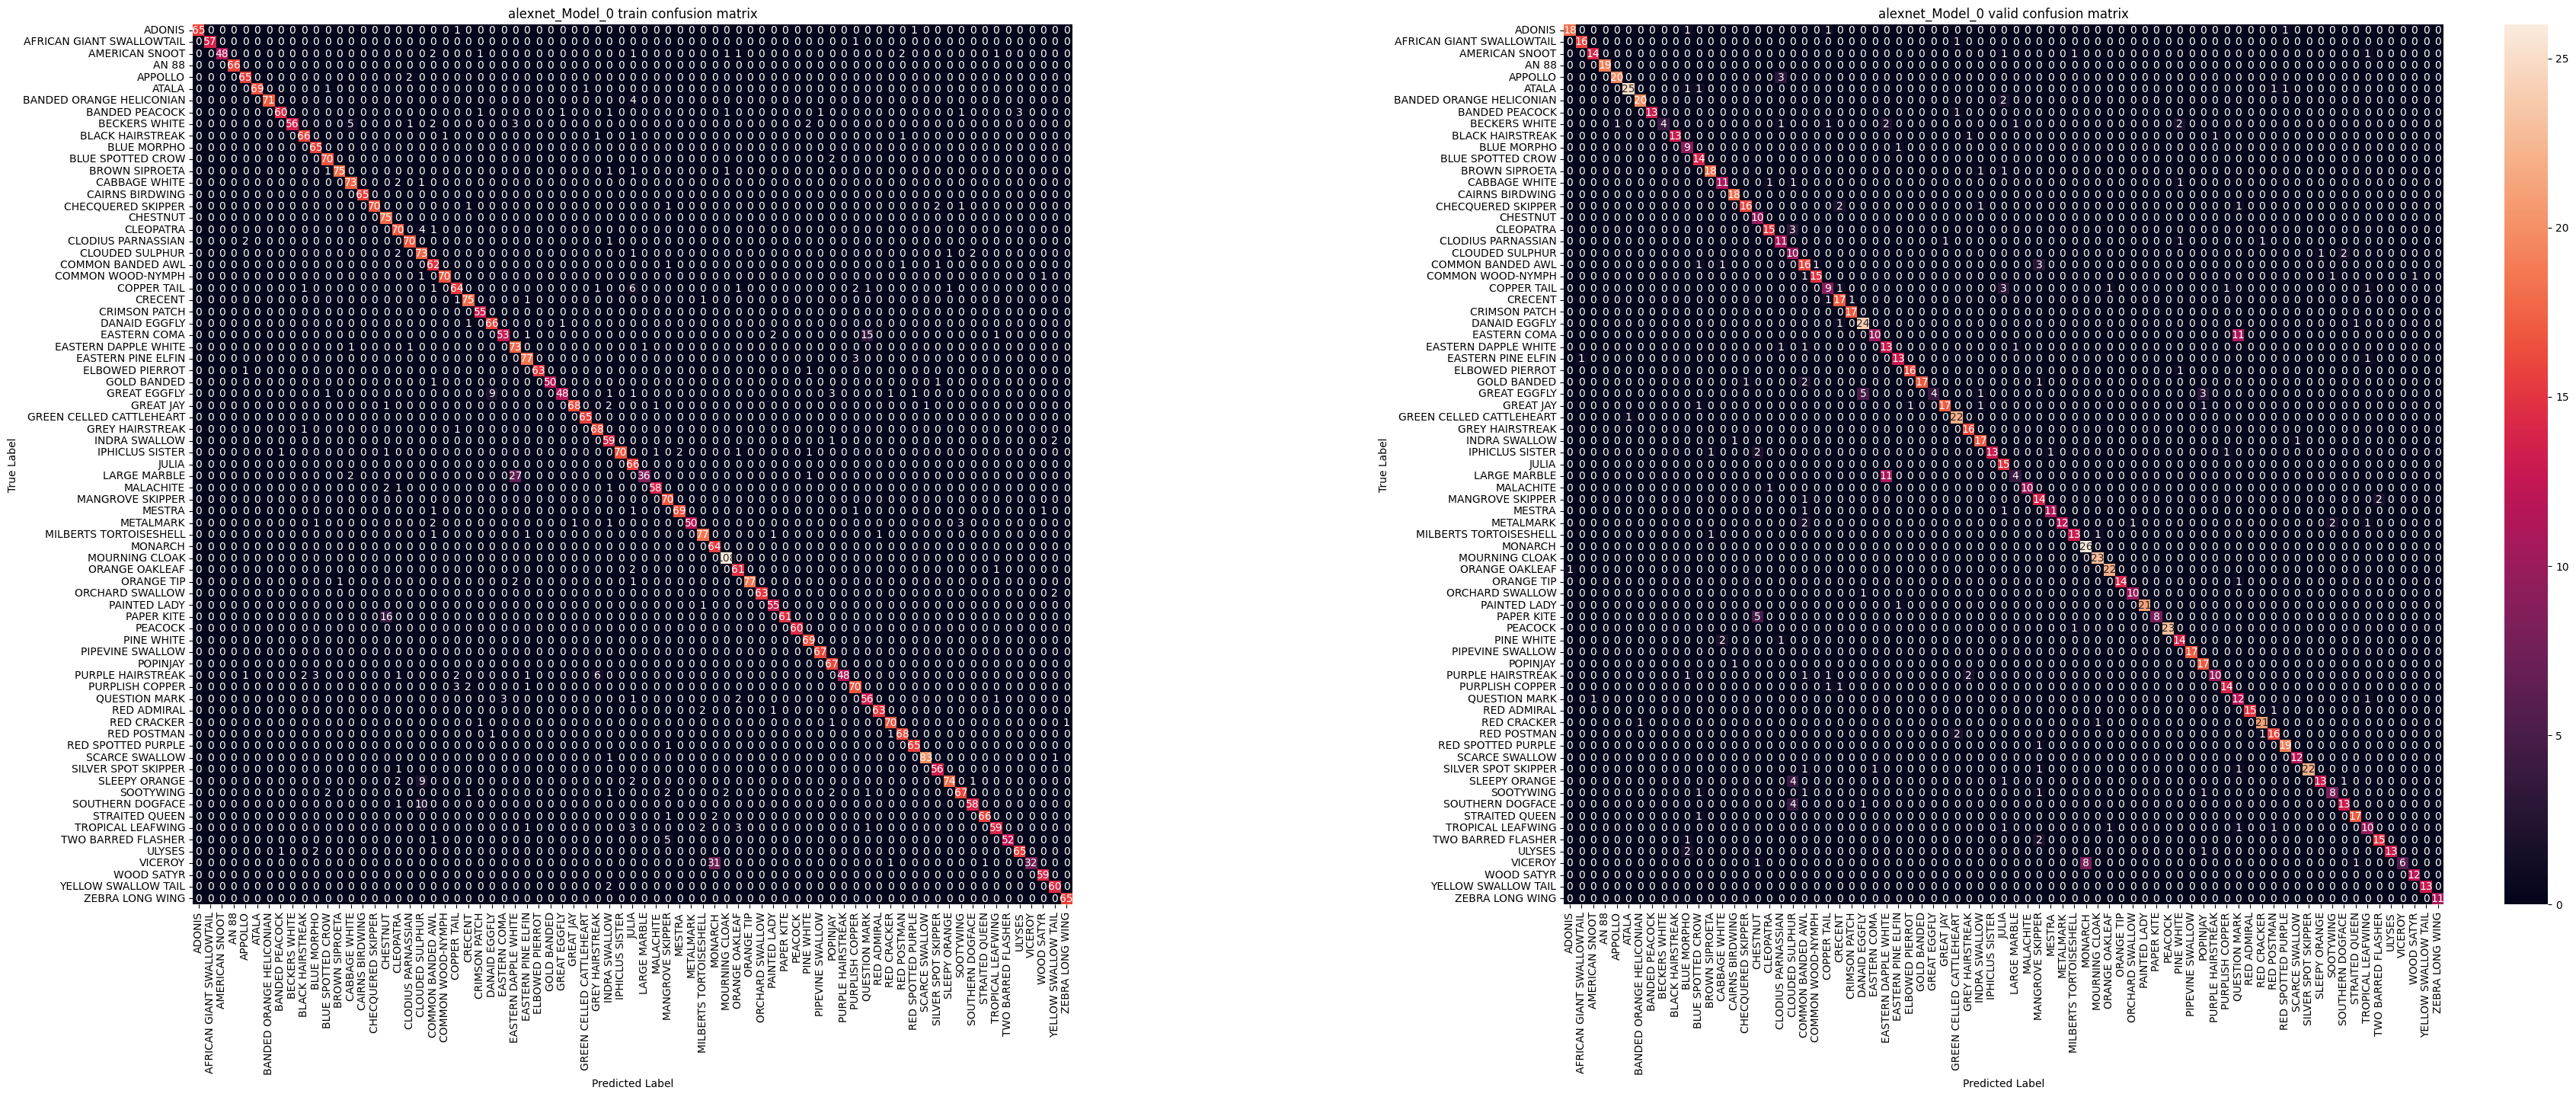

In [38]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

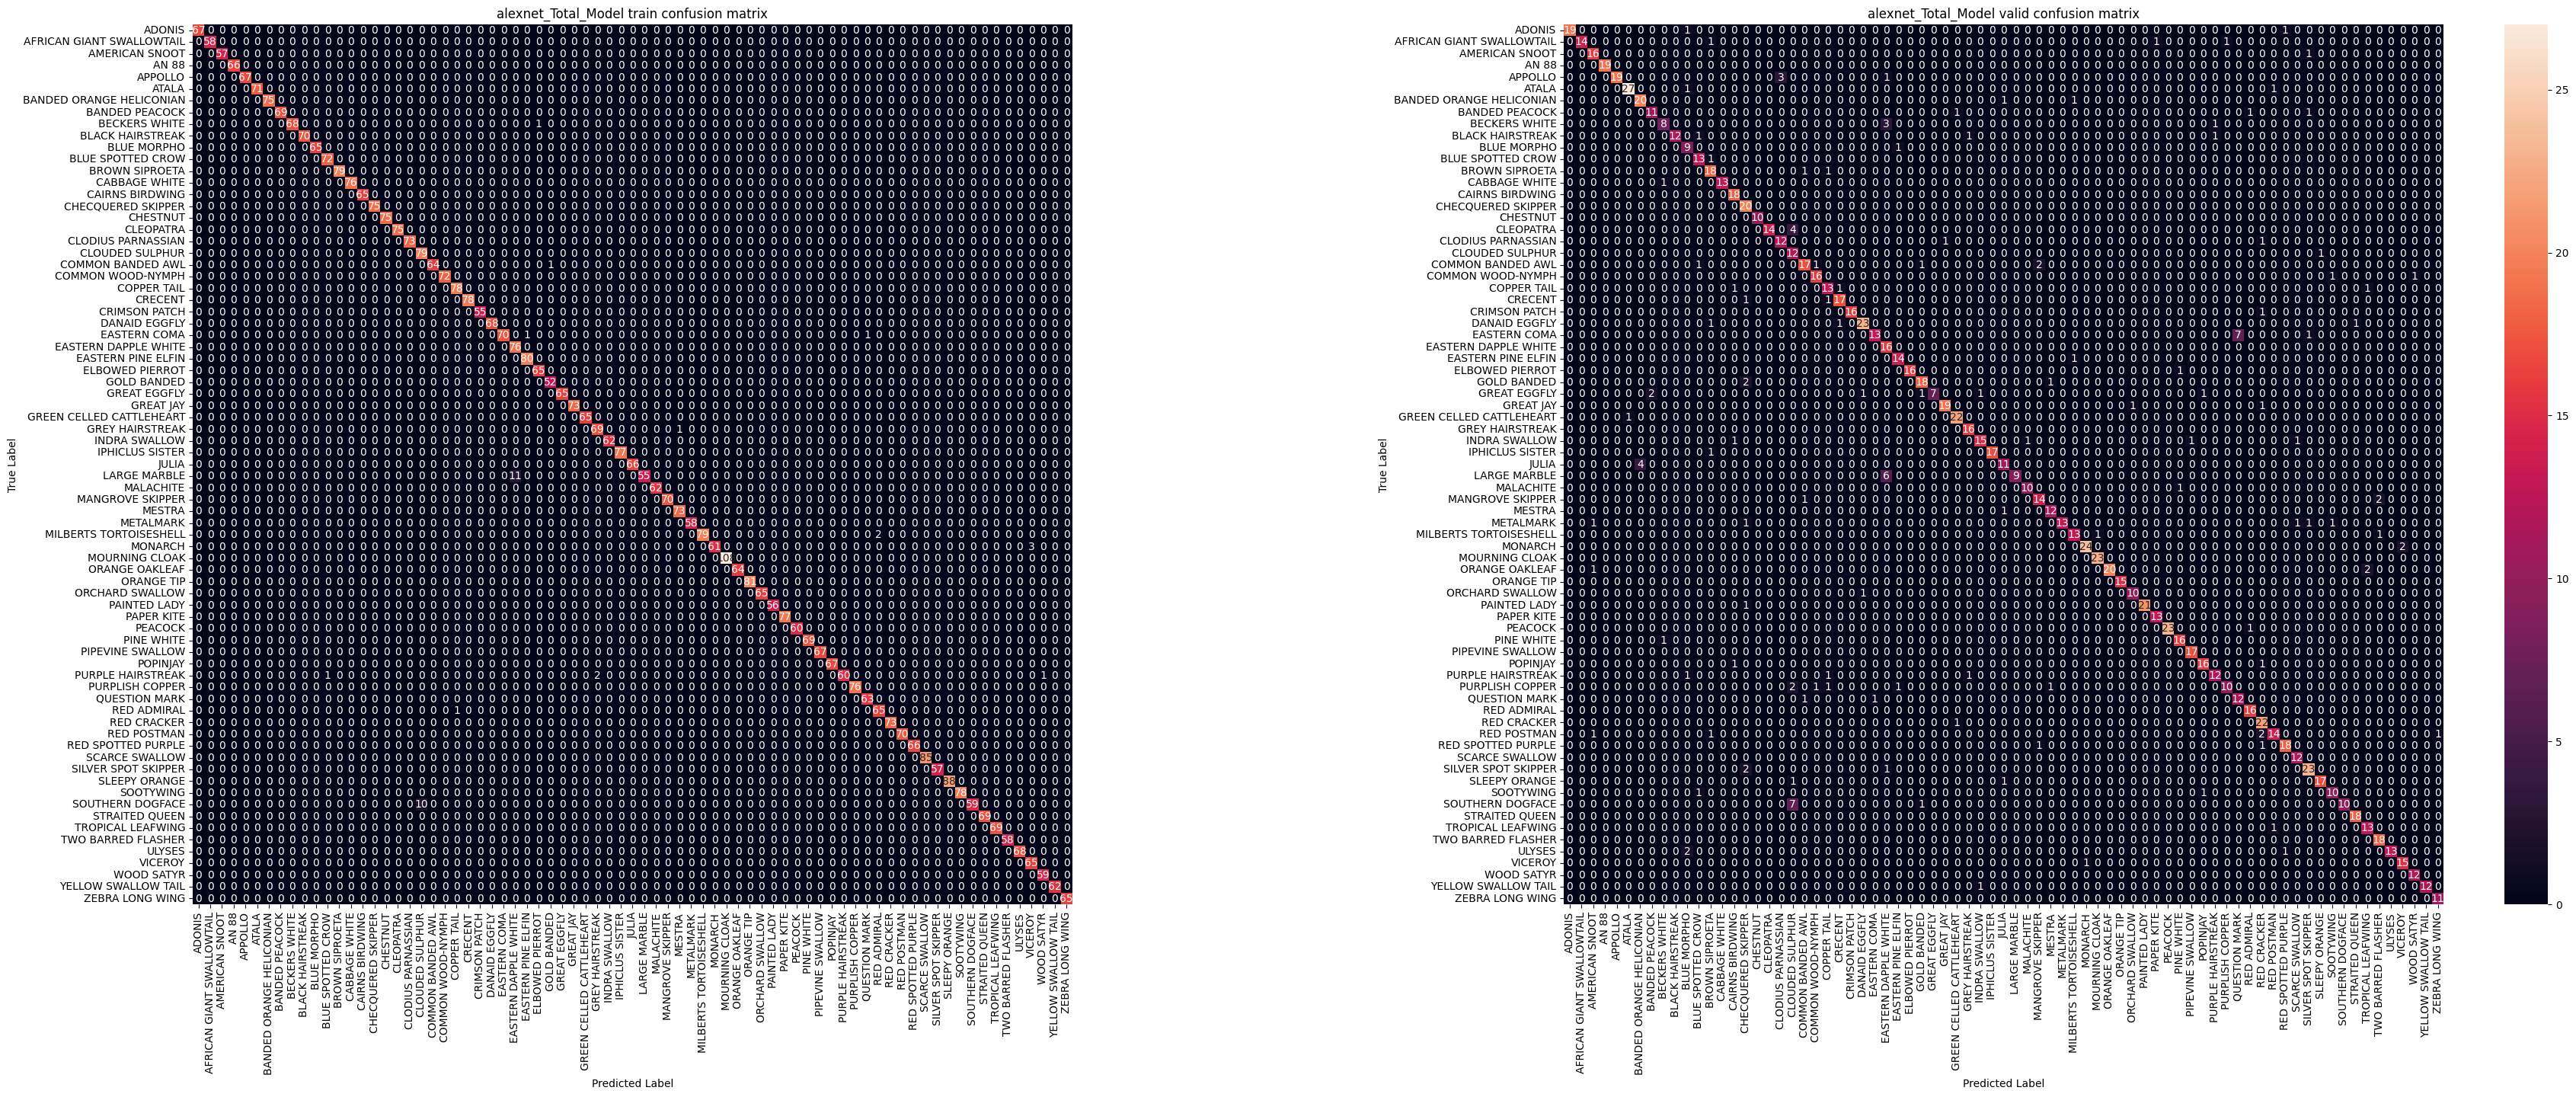

In [39]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

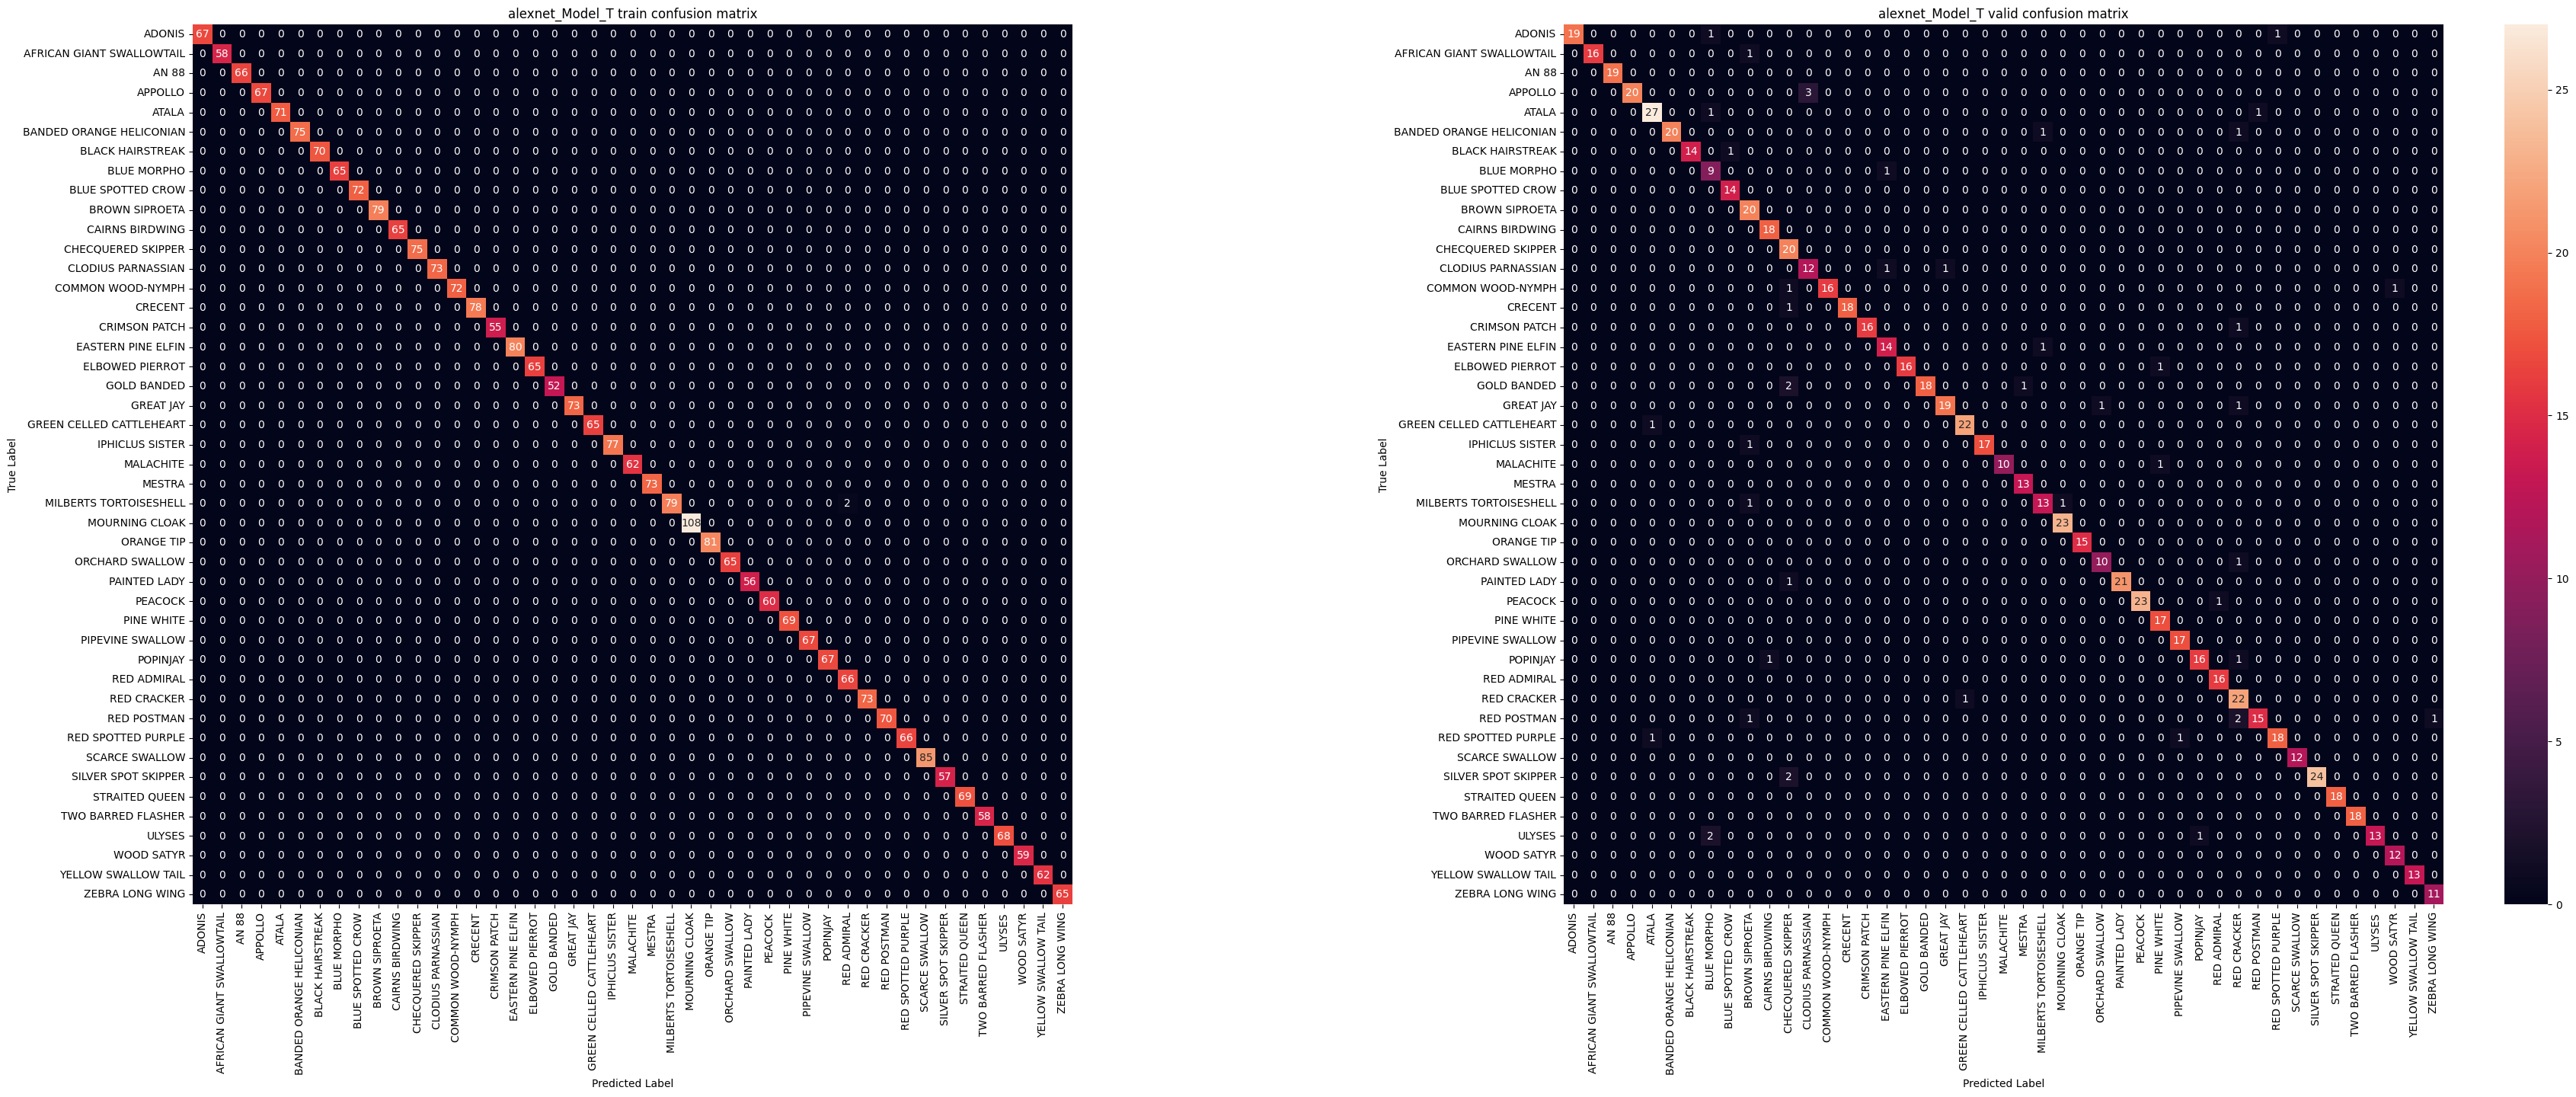

In [40]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

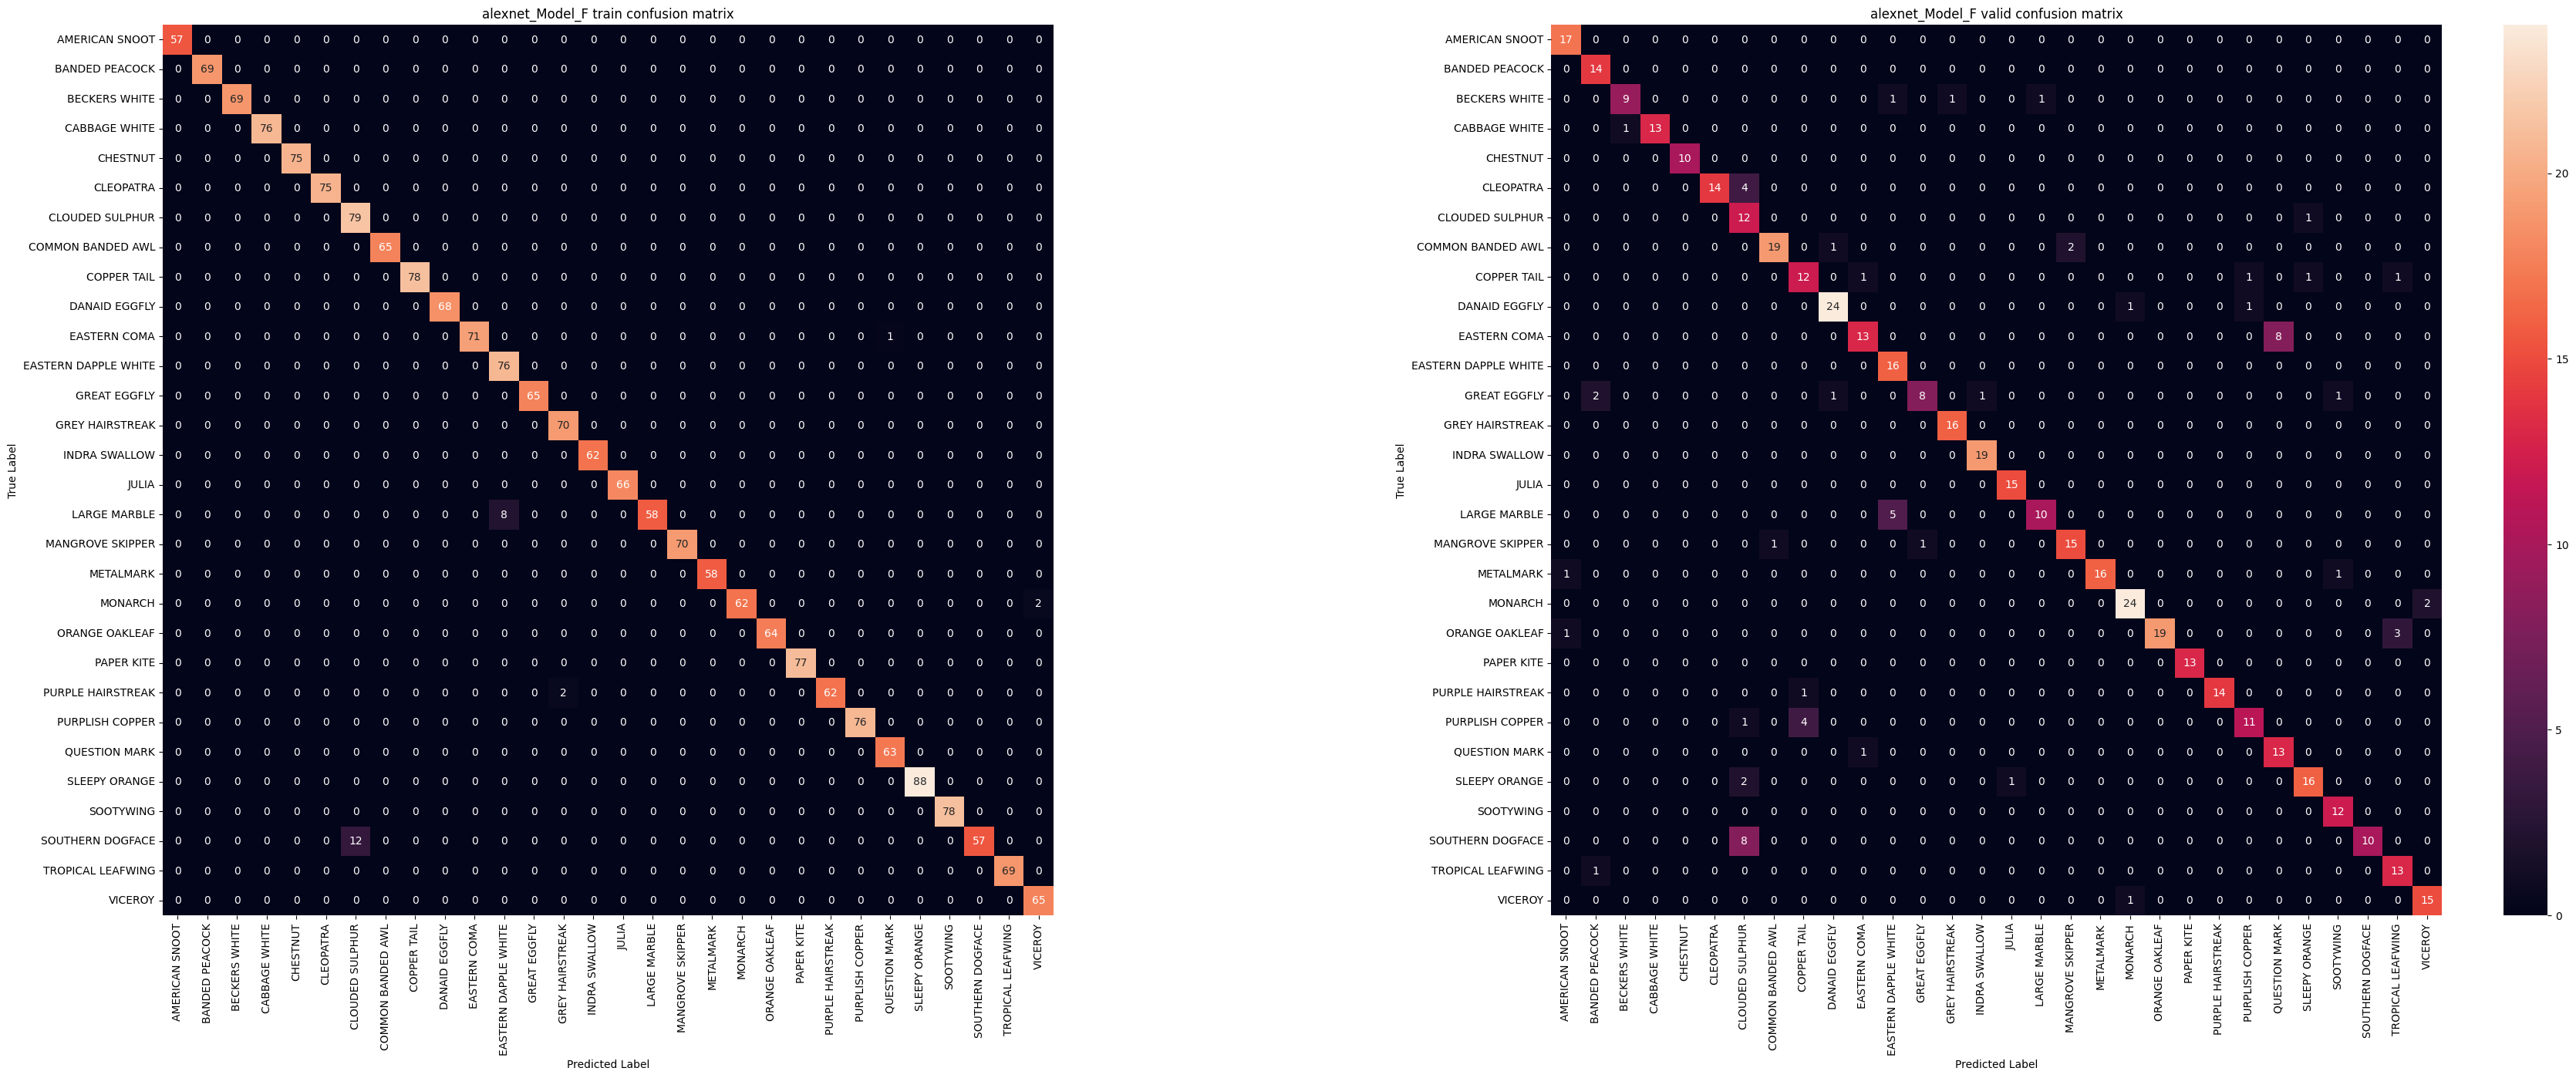

In [41]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [42]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,_,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [43]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,4388,14,35,14,14,0.497353,0.999906,0.972591,1.000000,False,True,True,True,True
1,3693,73,35,73,73,0.996796,0.999998,0.982378,0.999999,False,True,True,True,True
2,2059,19,19,21,19,0.999954,0.718121,0.881583,0.999998,True,False,True,False,False
3,3306,38,38,18,27,0.970724,0.896743,0.614025,1.000000,True,False,False,False,False
4,2685,31,31,54,31,0.999999,0.989464,0.904625,0.999955,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5195,1871,32,35,32,32,0.813988,0.999963,0.988546,1.000000,False,True,True,True,True
5196,6171,61,22,61,61,0.736106,0.999992,0.998620,0.999775,False,True,True,True,True
5197,3537,1,44,1,1,0.841718,0.999998,0.999911,0.999585,False,True,True,True,True
5198,682,20,20,11,20,0.998306,0.723992,0.986633,0.999970,True,False,True,False,False


In [44]:
len(df_results[df_results['Decision']!=df_results['flag']])

7

In [45]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
416,6106,20,20,30,20,0.996069,0.999418,0.458861,0.983360,True,False,True,True,False
471,2187,31,31,74,31,0.997776,0.942185,0.256305,0.751807,True,False,True,True,False
1370,223,56,56,28,56,0.938745,0.996283,0.287081,0.591091,True,False,True,True,False
1411,4870,26,26,28,26,0.962764,0.996935,0.537386,0.732753,True,False,True,True,False
1816,4117,55,55,72,4,0.995039,0.767333,0.175540,0.516903,True,False,False,True,False
2875,988,55,55,53,55,0.999958,0.584259,0.837744,0.705530,True,False,True,True,False
3023,880,55,55,11,55,0.906998,0.549531,0.206701,0.576907,True,False,True,True,False


In [46]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

55    3
20    1
31    1
56    1
26    1
Name: Target, dtype: int64

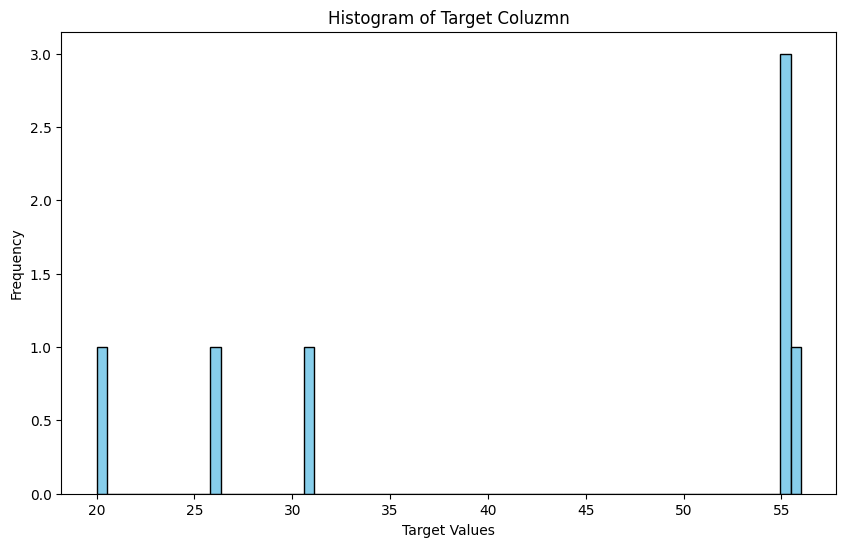

In [47]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [48]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,4576,42,42,32,42,0.999946,0.960822,0.912566,0.999927,True,False,True,False,False
1,3457,51,25,51,51,0.953623,0.993997,0.817902,0.988356,False,True,True,True,True
2,2484,34,34,9,34,0.999891,0.999998,0.827382,0.999989,True,False,True,False,False
3,3737,50,50,59,50,0.999987,0.995167,0.773466,1.000000,True,False,True,False,False
4,6475,51,22,51,51,0.283910,1.000000,0.999455,1.000000,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1294,4999,20,20,41,20,0.997590,0.391070,0.981592,0.998351,True,False,True,False,False
1295,1647,55,34,9,34,0.849030,0.496058,0.491710,0.974252,False,False,False,False,False
1296,5495,3,50,3,3,0.829680,1.000000,0.999987,1.000000,False,True,True,True,True
1297,388,39,16,39,39,0.720197,0.916231,0.762051,0.999948,False,True,True,True,True


In [49]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag'])])

52

In [50]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

37    4
42    3
7     3
20    3
22    3
35    3
56    2
2     2
40    2
65    2
25    2
31    2
1     1
73    1
41    1
23    1
52    1
48    1
33    1
24    1
12    1
21    1
9     1
68    1
4     1
60    1
61    1
8     1
55    1
6     1
66    1
57    1
26    1
Name: Target, dtype: int64

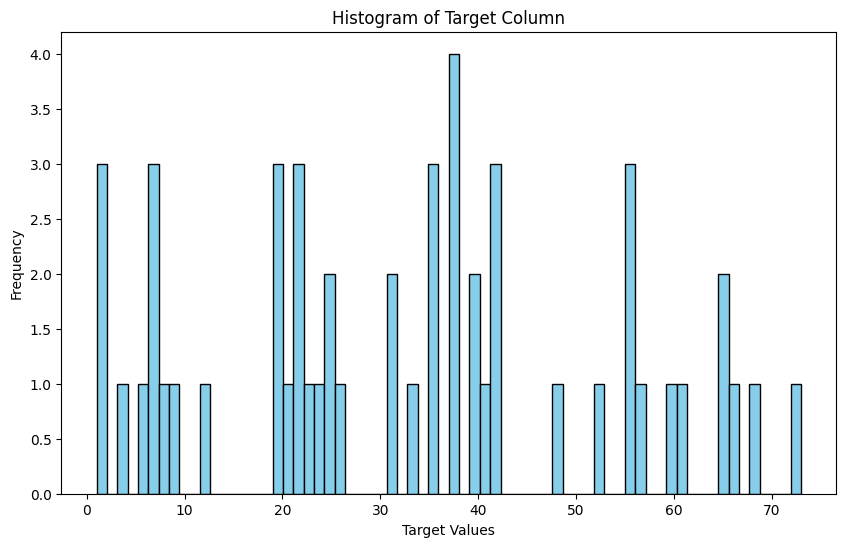

In [51]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()